# 📘 本章知识点总结：数据增广（Data Augmentation）

## 一、为什么需要数据增广？
深度模型容易在训练集上**过拟合**。数据增广通过对训练样本做**随机变换**生成"新"样本，
等价于人为扩大数据集、向数据中注入先验不变性，从而提升模型的**泛化能力与鲁棒性**。

> 核心思想：让模型在训练中见到同一物体的各种"变体"（不同角度、光照、位置），
> 迫使它学习到对这些变化**不敏感**的特征，而不是死记硬背训练图片。

## 二、常见的图像增广方法（本章演示）

| 类别 | torchvision 接口 | 作用 / 适用场景 |
|------|------------------|-----------------|
| 水平翻转 | `RandomHorizontalFlip()` | 最常用、最安全；左右对称的物体语义不变 |
| 垂直翻转 | `RandomVerticalFlip()` | 需谨慎；多数自然图像上下翻转后不合理（如人、车） |
| 随机裁剪 | `RandomResizedCrop(size, scale, ratio)` | 改变物体大小与位置；`scale` 控裁剪面积比例，`ratio` 控宽高比 |
| 颜色变换 | `ColorJitter(brightness, contrast, saturation, hue)` | 模拟不同光照/相机；4 个参数分别控亮度、对比度、饱和度、色调 |
| 组合 | `Compose([...])` | 将多个增广**按顺序**串联应用 |

## 三、关键实践原则（务必牢记）

1. **只在训练集上做随机增广，测试集不做**（或只做确定性变换如 `ToTensor`）。
   - 训练用 `train_augs`（含随机翻转），测试用 `test_augs`（仅 `ToTensor`）。
   - 原因：测试要的是**稳定、可复现**的评估，随机性会让结果抖动。
2. **增广是"在线"实时进行的**：每个 epoch、每次取样都重新随机变换，
   所以模型几乎不会看到两张完全相同的图。
3. **增广要符合数据语义**：选择的变换不能破坏标签的正确性
   （例如数字 6/9 不能上下翻转，交通标志不能随意改色）。

## 四、本章训练实验（CIFAR-10 + ResNet-18）

- 数据集：CIFAR-10（10 类、32×32 彩色小图）。
- 模型：`d2l.resnet18(10, 3)`（10 类输出、3 通道输入），Xavier 初始化。
- 优化器：`Adam`（对学习率不敏感，适合快速实验）。
- 训练框架：`train_ch13` 使用 `nn.DataParallel` 支持**多 GPU 并行**。

> ⚠️ 注意实验中的"陷阱"：本 notebook 中第二次训练（无增广）复用了**第一次已训练过的同一个 `net`**，
> 因此它的 test acc 看起来更高并不能直接说明"无增广更好"——它是在已学习的权重上继续训练的。
> 严谨的对照实验应当为每组配置**重新初始化模型**。

## 五、一句话总结
> 数据增广 = 用随机变换"免费"扩充训练数据，是提升泛化、对抗过拟合的**性价比最高**的手段之一，
> 几乎是现代 CV 训练的标配。


# 1. 数据增广

## 数据增广

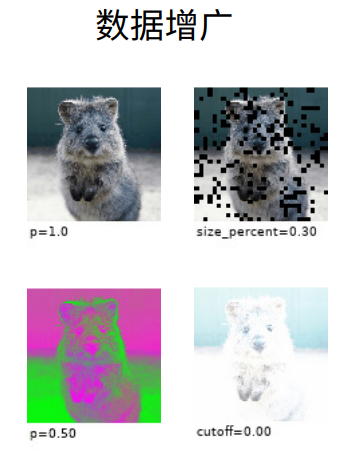

## CSE上的真实故事

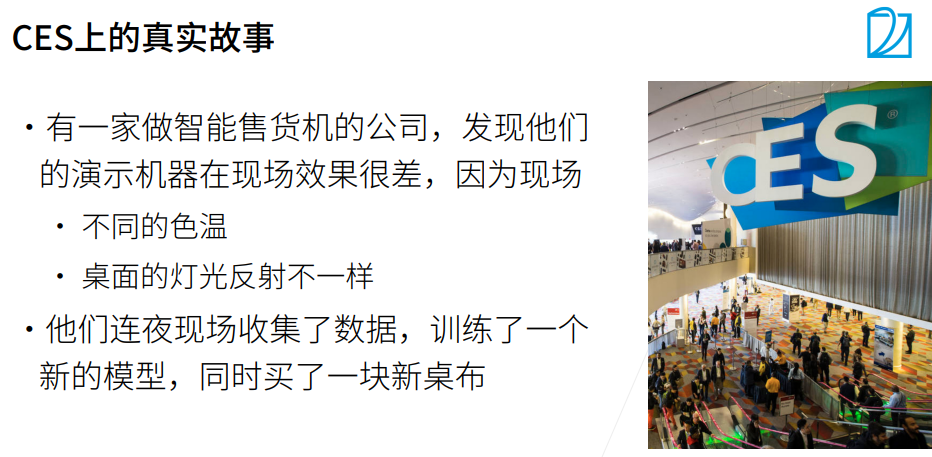

## 数据增强

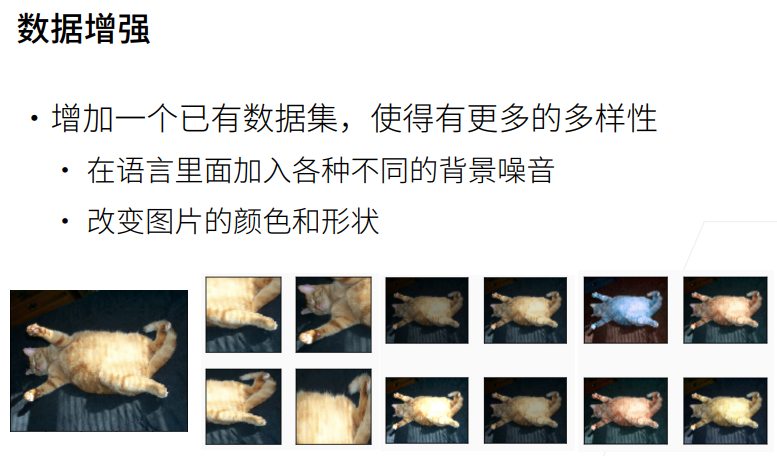

## 使用增强数据训练

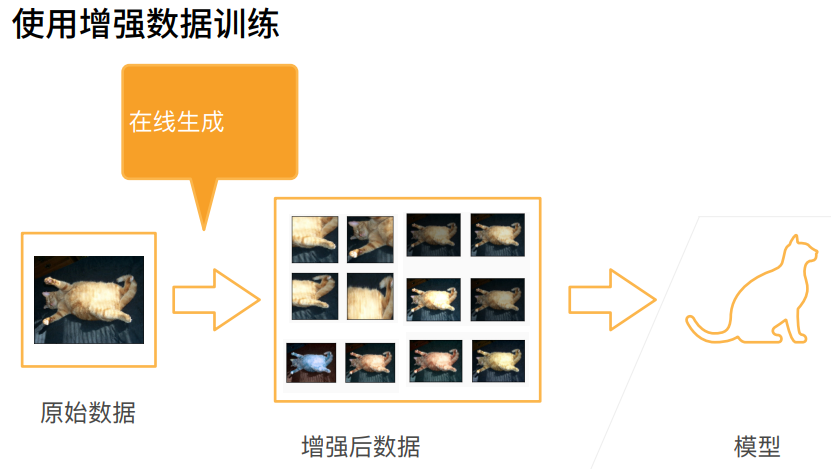

## 翻转

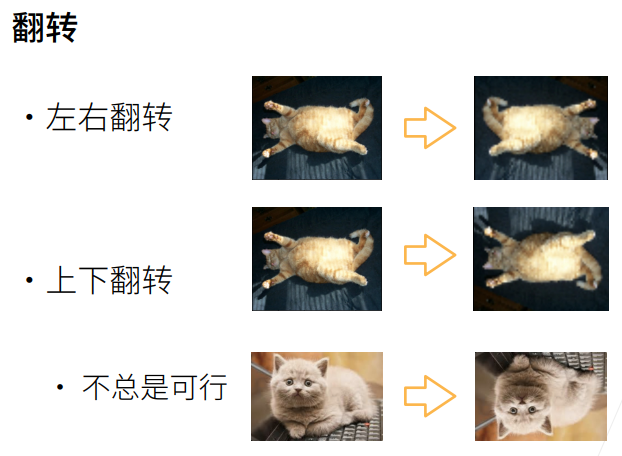

## 切割

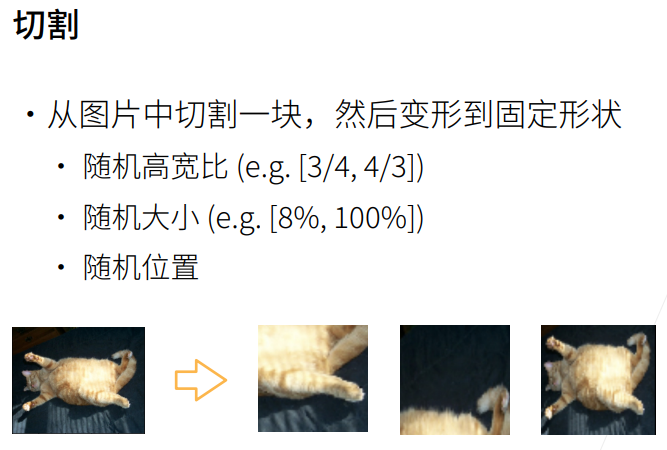

## 颜色

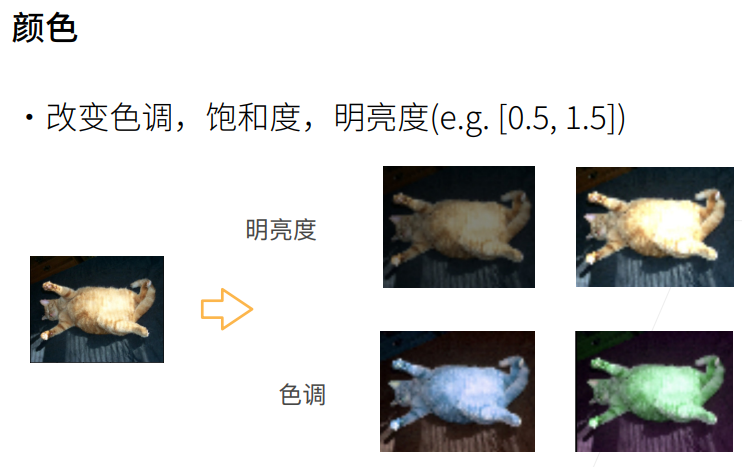

## imgaug

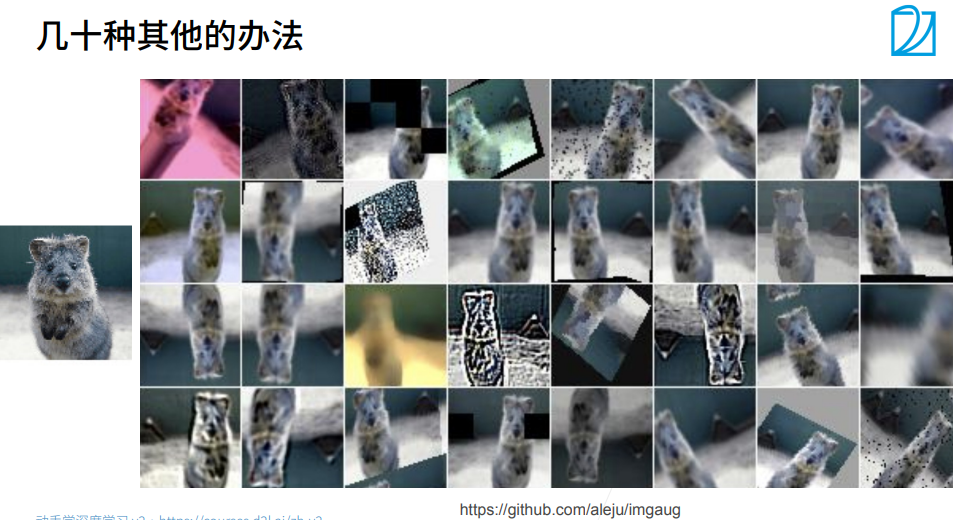

# 2. 总结

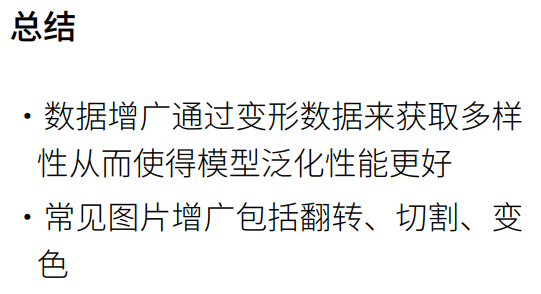

# 1. 数据增广

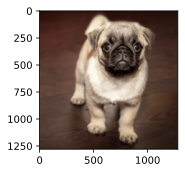

In [5]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

# set_figsize() 设置 matplotlib 输出图像的默认尺寸（d2l 的便捷封装）
d2l.set_figsize()
# d2l.Image 即 PIL.Image，这里读取一张狗的图片作为演示素材
img = d2l.Image.open('../img/dog1.jpg')  # 读取图片
d2l.plt.imshow(img)  # 显示原始图片

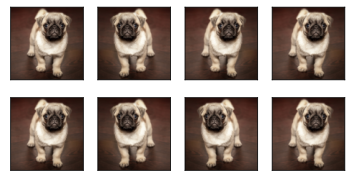

In [6]:
# apply: 把某个增广方法 aug 重复作用在同一张图上多次，并以网格形式展示效果
#   img      : 输入图片
#   aug      : torchvision 的图像增广变换（可调用对象）
#   num_rows/num_cols : 展示网格的行数/列数（默认 2x4 = 8 张）
#   scale    : 每张子图的缩放比例
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    # 对同一张图调用 aug 共 num_rows*num_cols 次；由于增广是随机的，每次结果都不同
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    # show_images 是 d2l 的工具函数，把图片列表按网格排布显示
    d2l.show_images(Y, num_rows, num_cols, scale=scale)

# RandomHorizontalFlip(): 以 50% 概率水平（左右）翻转图片——最常用、最安全的增广
apply(img, torchvision.transforms.RandomHorizontalFlip())

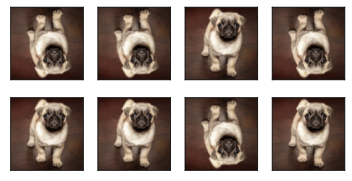

In [7]:
# RandomVerticalFlip(): 以 50% 概率垂直（上下）翻转
# 注意：上下翻转对很多自然图像（人、车、动物）不合理，需根据任务谨慎使用
apply(img, torchvision.transforms.RandomVerticalFlip())

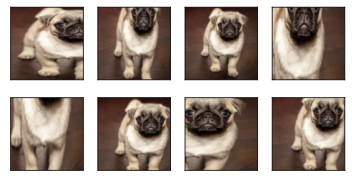

In [8]:
# RandomResizedCrop: 随机裁剪图片的一块区域，再缩放到指定大小 (200, 200)
#   scale=(0.1, 1) : 裁剪区域面积占原图的 10%~100%（控制"裁多大")
#   ratio=(0.5, 2) : 裁剪区域的宽高比在 0.5~2 之间（控制"裁成什么形状")
# 该增广同时改变了物体在图中的【大小】和【位置】，是非常强的增广手段
shape_aug = torchvision.transforms.RandomResizedCrop(
    (200, 200), scale=(0.1, 1), ratio=(0.5, 2))
apply(img, shape_aug)

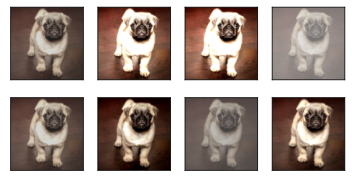

In [13]:
# ColorJitter 的四个参数都接受一个非负数 x，表示在 [max(0,1-x), 1+x] 范围内随机抖动
# 这里只改变【亮度 brightness】和【对比度 contrast】，饱和度/色调保持不变（设为 0）
apply(img, torchvision.transforms.ColorJitter(
    brightness=0.8, contrast=0.8, saturation=0, hue=0))

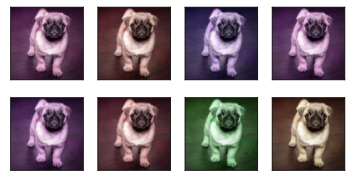

In [10]:
# 只随机改变【色调 hue】（hue 的取值范围是 [-0.5, 0.5]）
# 色调变化会让物体呈现不同的颜色（如把黄色狗变成偏蓝/偏绿）
apply(img, torchvision.transforms.ColorJitter(
    brightness=0, contrast=0, saturation=0, hue=0.5))

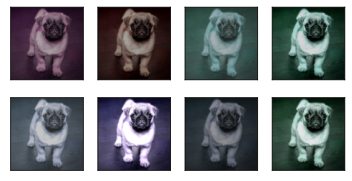

In [11]:
# 同时随机更改亮度(brightness)、对比度(contrast)、饱和度(saturation)、色调(hue)
# 这是一个综合的颜色增广，模拟不同相机、不同光照条件下的成像差异
color_aug = torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

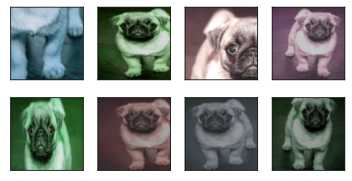

In [12]:
# Compose 把多个增广【按顺序】串联成一个组合变换
# 这里的顺序：先随机水平翻转 -> 再做颜色增广 -> 最后做形状(裁剪)增广
# 实战中通常会组合多种增广，让模型见到更丰富的样本变体
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    color_aug,
    shape_aug])
apply(img, augs)

  0%|          | 0/170498071 [00:00<?, ?it/s]

Extracting 01_Data/03_CIFAR10/cifar-10-python.tar.gz to 01_Data/03_CIFAR10


array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
       <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>],
      dtype=object)

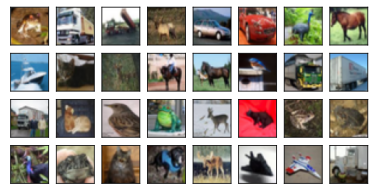

In [15]:
# 下载 CIFAR-10 训练集（10 类、32x32 彩色小图），并展示前 32 张
#   root     : 数据存放目录；download=True 表示本地没有时自动下载
#   此处暂不传 transform，返回的是 PIL 图片，便于直接可视化
all_images = torchvision.datasets.CIFAR10(
    train=True, root='01_Data/03_CIFAR10', download=True)
# 取前 32 张图片 (all_images[i][0] 是图片，[1] 是标签)，用 4 行 8 列展示
d2l.show_images([all_images[i][0] for i in range(32)], 4, 8, scale=0.8)

In [17]:
# 训练集增广：随机左右翻转 + 转成张量
#   ToTensor() 会把 PIL 图片 (H,W,C, 像素 0~255) 转为 Tensor (C,H,W, 归一化到 0~1)
# 【关键】只对训练集做随机增广，目的是扩充训练数据、提升泛化
train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor()])

# 测试集【不做】随机增广，只做必要的 ToTensor，保证评估结果稳定可复现
test_augs = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()])

In [18]:
# 辅助函数：根据是否训练集加载 CIFAR-10，并套用对应的增广，返回 DataLoader
def load_cifar10(is_train, augs, batch_size):
    # transform=augs 让 DataLoader 在【每次取数据时】实时应用增广（在线增广）
    dataset = torchvision.datasets.CIFAR10(
        root='01_Data/03_CIFAR10', train=is_train,
        transform=augs, download=True)
    # shuffle=is_train: 训练时打乱顺序，测试时不打乱
    # num_workers=0: 不开子进程加载（Windows/部分环境更稳；可按机器情况调大加速）
    dataloader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=is_train, num_workers=0)
    return dataloader

In [19]:
# train_batch_ch13: 完成【一个小批量】的多 GPU 训练，返回该批量的损失和正确数
def train_batch_ch13(net, X, y, loss, trainer, devices):
    if isinstance(X, list):
        # 若 X 是 list（多输入场景，如目标检测），逐个搬到主 GPU(devices[0])
        X = [x.to(devices[0]) for x in X]
    else:
        # 否则直接把 X 搬到主 GPU
        X = X.to(devices[0])
    y = y.to(devices[0])
    net.train()              # 切换到训练模式（启用 dropout / BN 的训练行为）
    trainer.zero_grad()      # 清空上一步的梯度
    pred = net(X)            # 前向传播得到预测
    l = loss(pred, y)        # 计算损失（注意 loss 用 reduction='none'，返回逐样本损失）
    l.sum().backward()       # 对总损失反向传播求梯度
    trainer.step()           # 用梯度更新参数
    train_loss_sum = l.sum()                 # 该批量的损失之和
    train_acc_sum = d2l.accuracy(pred, y)    # 该批量预测正确的样本数
    return train_loss_sum, train_acc_sum

# train_ch13: 完整训练循环，支持多 GPU，并用 Animator 动态绘制训练曲线
def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
               devices=d2l.try_all_gpus()):
    timer, num_batches = d2l.Timer(), len(train_iter)
    # Animator 实时绘制 训练损失/训练精度/测试精度 三条曲线
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                            legend=['train loss', 'train acc', 'test acc'])
    # nn.DataParallel: 把模型复制到多块 GPU 上做数据并行，再汇总梯度
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    for epoch in range(num_epochs):
        # Accumulator(4) 累加 4 个量：损失和、正确数、样本数、标签元素数
        metric = d2l.Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(net, features, labels, loss, trainer, devices)
            metric.add(l, acc, labels.shape[0], labels.numel())
            timer.stop()
            # 每个 epoch 内画 5 次中间点，让训练曲线更平滑
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(
                    epoch + (i + 1) / num_batches,
                    (metric[0] / metric[2], metric[1] / metric[3], None))
        # 每个 epoch 结束后在测试集上评估精度
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    # 打印最终的损失、训练精度、测试精度，以及训练吞吐（样本/秒）
    print(f'loss {metric[0] / metric[2]:.3f}, train acc'
          f' {metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f' {metric[2] * num_epochs / timer.sum():.1f} examples/sec on '
          f' {str(devices)}')

loss 0.171, train acc 0.939, test acc 0.829
 2473.3 examples/sec on  [device(type='cuda', index=0)]


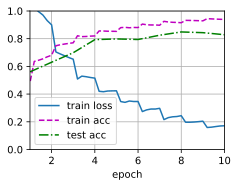

In [20]:
# 准备：批大小、可用 GPU 列表、ResNet-18 模型（10 类输出、3 通道输入）
batch_size, devices, net = 256, d2l.try_all_gpus(), d2l.resnet18(10, 3)

# 自定义权重初始化：对全连接层和卷积层使用 Xavier 均匀初始化（利于训练稳定）
def init_weights(m):
    if type(m) in [nn.Linear, nn.Conv2d]:
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights)  # 递归地把 init_weights 应用到网络每一层

# train_with_data_aug: 给定训练/测试增广，加载数据并训练模型
def train_with_data_aug(train_augs, test_augs, net, lr=0.001):
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    # reduction='none' 返回逐样本损失，便于上面 train_batch_ch13 里手动 .sum()
    loss = nn.CrossEntropyLoss(reduction="none")
    # Adam 优化器：可看作更平滑的 SGD，对学习率不敏感，适合快速实验
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    train_ch13(net, train_iter, test_iter, loss, trainer, 10, devices)

# 第①次训练：训练集【使用】随机翻转增广
train_with_data_aug(train_augs, test_augs, net)

loss 0.033, train acc 0.989, test acc 0.854
 2485.1 examples/sec on  [device(type='cuda', index=0)]


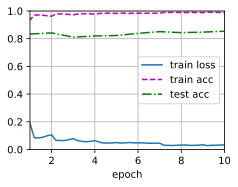

In [21]:
# 第②次训练：训练集也改用 test_augs（即【不做】随机增广）作为对照
# ⚠️ 注意：这里复用了上一格已经训练过的同一个 net，权重并未重置，
#    因此该结果不能简单解读为"无增广更好"——严谨对照应重新初始化模型。
train_with_data_aug(test_augs, test_augs, net)